# GlassScan Pipeline Runner

Run the full pipeline: load buildings, fetch Street View images, segment facades, compute WWR, export to dashboard.

**Hackathon day:** Only change **Section 1** (Load Buildings) to point at SDSC's data file.

In [1]:
import os, sys, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Avoid libomp conflict between PyTorch and XGBoost on macOS
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

API_KEY = os.environ["GOOGLE_API_KEY"]
OUTPUT_DIR = PROJECT_ROOT / "data" / "zurich_central"
DASHBOARD_DIR = PROJECT_ROOT / "src" / "glassscan" / "visualise" / "dashboard" / "public"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: /Users/lukemarinos/WORK/glassscan
Output dir:   /Users/lukemarinos/WORK/glassscan/data/zurich_central


## 1. Load Buildings

**This is the only section you change on hackathon day.**

Currently queries the Swiss GWR (building register) API for central Zurich.
On hackathon day, replace with something like:
```python
buildings_df = pd.read_csv("path/to/sdsc_data.csv")
```
Just make sure the DataFrame has columns: `egid`, `lat`, `lon`.

In [2]:
import requests

# --- SWAP THIS CELL ON HACKATHON DAY ---
# Replace everything below with: buildings_df = pd.read_csv("path/to/sdsc_data.csv")

GWR_URL = "https://api3.geo.admin.ch/rest/services/api/MapServer/identify"
GWR_LAYER = "ch.bfs.gebaeude_wohnungs_register"

# Central Zurich: Bahnhofstrasse / Paradeplatz / Altstadt (~800m x 500m)
BBOX = {"south": 47.369, "north": 47.376, "west": 8.537, "east": 8.544}

CACHE_PATH = OUTPUT_DIR / "buildings.csv"


def fetch_gwr_buildings(bbox, tile_size=0.002):
    """Fetch building data from Swiss GWR API, tiling to handle result limits."""
    buildings = []
    seen = set()

    lat = bbox["south"]
    while lat < bbox["north"]:
        lon = bbox["west"]
        while lon < bbox["east"]:
            tile_n = min(lat + tile_size, bbox["north"])
            tile_e = min(lon + tile_size, bbox["east"])
            geom = f"{lon},{lat},{tile_e},{tile_n}"

            resp = requests.get(GWR_URL, params={
                "geometry": geom,
                "geometryType": "esriGeometryEnvelope",
                "sr": "4326",
                "layers": f"all:{GWR_LAYER}",
                "returnGeometry": "true",
                "tolerance": "0",
                "mapExtent": geom,
                "imageDisplay": "100,100,96",
            }, timeout=30)
            resp.raise_for_status()
            results = resp.json().get("results", [])

            for r in results:
                attrs = r.get("attributes", {})
                egid = str(attrs.get("egid", ""))
                if not egid or egid in seen:
                    continue
                seen.add(egid)

                g = r.get("geometry", {})
                if g.get("y") and g.get("x"):
                    buildings.append({
                        "egid": egid,
                        "lat": g["y"],
                        "lon": g["x"],
                        "construction_year": attrs.get("gbauj"),
                        "storeys": attrs.get("gastw"),
                        "area_m2": attrs.get("garea"),
                        "building_category": attrs.get("gkat"),
                    })

            lon += tile_size
        lat += tile_size

    return buildings


# Use cache if available, otherwise query API
if CACHE_PATH.exists():
    buildings_df = pd.read_csv(CACHE_PATH)
    print(f"Loaded {len(buildings_df)} buildings from cache")
else:
    raw = fetch_gwr_buildings(BBOX)
    buildings_df = pd.DataFrame(raw)
    buildings_df.to_csv(CACHE_PATH, index=False)
    print(f"Fetched {len(buildings_df)} buildings from GWR, cached to {CACHE_PATH}")

buildings_df.head()

Loaded 655 buildings from cache


,egid,lat,lon,construction_year,storeys,area_m2,building_category
0,302019765,47.370078,8.537530,2003.0,1,1318,1080
1,9083941,47.369305,8.537250,1951.0,8,385,1060
2,2372981,47.370689,8.538338,1925.0,8,1288,1060
3,141006,47.369013,8.538246,1886.0,7,479,1040
4,2372795,47.369387,8.538848,1856.0,7,252,1060


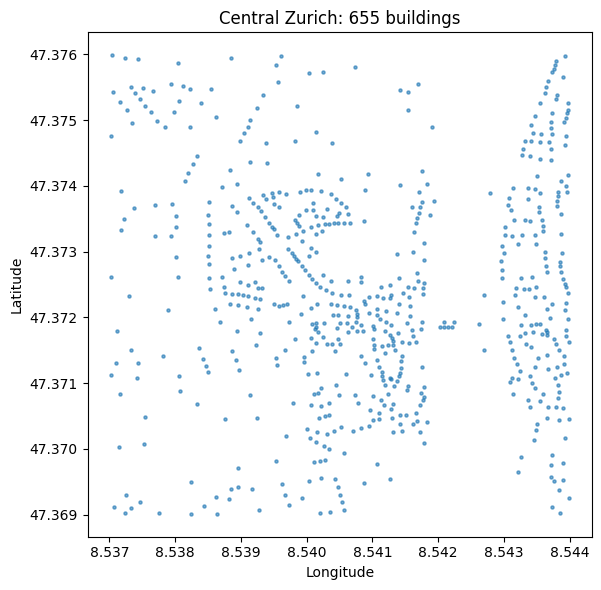

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(buildings_df["lon"], buildings_df["lat"], s=5, alpha=0.6)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Central Zurich: {len(buildings_df)} buildings")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. Run CV Pipeline

Fetches Street View images, segments facades (wall/window), rectifies perspective, computes WWR.

- ~1 API call per building ($7/1000 calls, free tier covers ~28k/month)
- Segmentation takes ~5-10s per image on CPU
- Images already on disk are skipped automatically

In [5]:
# Reload results from disk (use after kernel restart)
import cv2
from glassscan.types import BuildingImage, SegmentationResult, RectifiedResult
from glassscan.wwr import compute_wwr_batch, aggregate_wwr
from glassscan.pipeline import PipelineResult

buildings_df["egid"] = buildings_df["egid"].astype(str)
coords = buildings_df.set_index("egid")[["lat", "lon"]].to_dict("index")
result = PipelineResult()

for p in sorted((OUTPUT_DIR / "raw").glob("*.jpg")):
    stem = p.stem
    # Parse EGID and view_index from filename: {egid}.jpg or {egid}_v{i}.jpg
    if "_v" in stem:
        egid, vi_str = stem.rsplit("_v", 1)
        vi = int(vi_str)
    else:
        egid = stem
        vi = 0

    if egid not in coords:
        continue
    img = cv2.imread(str(p))
    if img is None:
        continue
    c = coords[egid]
    result.images.append(BuildingImage(
        egid=egid, image=img, lat=c["lat"], lon=c["lon"],
        heading=0, pitch=20, fov=70, view_index=vi,
    ))

    # Load view-specific mask (falls back to primary if view-specific doesn't exist)
    suffix = f"_v{vi}" if vi > 0 else ""
    mask_path = OUTPUT_DIR / "masks" / f"{egid}{suffix}_mask.png"
    if not mask_path.exists() and vi > 0:
        mask_path = OUTPUT_DIR / "masks" / f"{egid}_mask.png"  # legacy fallback
    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        result.segmentations.append(SegmentationResult(
            egid=egid, mask=mask, confidence=1.0,
            original_image=img, view_index=vi,
        ))

    rect_path = OUTPUT_DIR / "rectified" / f"{egid}{suffix}_rectified.jpg"
    rect_mask_path = OUTPUT_DIR / "rectified" / f"{egid}{suffix}_rectified_mask.png"
    if not rect_path.exists() and vi > 0:
        rect_path = OUTPUT_DIR / "rectified" / f"{egid}_rectified.jpg"
        rect_mask_path = OUTPUT_DIR / "rectified" / f"{egid}_rectified_mask.png"
    if rect_path.exists() and rect_mask_path.exists():
        rect_img = cv2.imread(str(rect_path))
        rect_mask = cv2.imread(str(rect_mask_path), cv2.IMREAD_GRAYSCALE)
        result.rectified.append(RectifiedResult(
            egid=egid, rectified_image=rect_img, rectified_mask=rect_mask,
            homography=np.eye(3), view_index=vi,
        ))

raw_wwr = compute_wwr_batch(result.rectified)
result.wwr_results = aggregate_wwr(raw_wwr)
wwrs = [r.wwr for r in result.wwr_results]
print(f"Reloaded: {len(result.images)} images, {len(raw_wwr)} per-view WWR, {len(result.wwr_results)} buildings (mean={np.mean(wwrs):.3f})")

2026-04-19 17:18:22,623 INFO EGID 11515820: WWR=0.180 (71183 window px / 394609 facade px), 9 windows, conf=1.00
2026-04-19 17:18:22,625 INFO EGID 11515820: WWR=0.179 (69971 window px / 390876 facade px), 9 windows, conf=1.00
2026-04-19 17:18:22,625 INFO EGID 11515820: WWR=0.210 (66519 window px / 317387 facade px), 19 windows, conf=1.00
2026-04-19 17:18:22,626 INFO EGID 11524801: WWR=0.240 (82816 window px / 345393 facade px), 47 windows, conf=1.00
2026-04-19 17:18:22,627 INFO EGID 11524801: WWR=0.241 (67480 window px / 279764 facade px), 22 windows, conf=1.00
2026-04-19 17:18:22,627 INFO EGID 11524801: WWR=0.094 (26432 window px / 281004 facade px), 16 windows, conf=1.00
2026-04-19 17:18:22,628 INFO EGID 140040: WWR=0.088 (35748 window px / 407619 facade px), 4 windows, conf=1.00
2026-04-19 17:18:22,629 INFO EGID 140040: WWR=0.133 (53860 window px / 404466 facade px), 13 windows, conf=1.00
2026-04-19 17:18:22,629 INFO EGID 140040: WWR=0.118 (35994 window px / 304337 facade px), 6 win

Reloaded: 1953 images, 1953 per-view WWR, 651 buildings (mean=0.161)


In [8]:
import subprocess, time

# Prevent Mac from sleeping during the run
caff = subprocess.Popen(["caffeinate", "-i", "-w", str(os.getpid())])
print("caffeinate started (Mac won't sleep)")

from glassscan.fetch import fetch_batch
from glassscan.segment import load_model, segment_batch
from glassscan.rectify import rectify_batch
from glassscan.wwr import compute_wwr_batch, aggregate_wwr
from glassscan.pipeline import PipelineResult

pipeline_input = buildings_df[["egid", "lat", "lon"]].to_dict("records")
result = PipelineResult()

# --- Step 1: Fetch images (disk cache skips existing, only bills new views) ---
print(f"\n--- Fetching images for {len(pipeline_input)} buildings ---")
t0 = time.time()
result.images = fetch_batch(
    pipeline_input, API_KEY,
    save_dir=OUTPUT_DIR / "raw", max_calls=2000, max_views=3,
)
print(f"Fetched {len(result.images)} images in {time.time() - t0:.0f}s")

# --- Step 2: Segment facades (slow, ~5-10s per image on CPU) ---
print(f"\n--- Segmenting {len(result.images)} images ---")
print("Loading models (~680 MB, may take a minute first time)...")
models = load_model()
print("Models loaded")

masks_dir = OUTPUT_DIR / "masks"
result.segmentations = []
chunk_size = 20
t0 = time.time()

for i in range(0, len(result.images), chunk_size):
    chunk = result.images[i : i + chunk_size]
    segs = segment_batch(chunk, models, save_dir=masks_dir)
    result.segmentations.extend(segs)
    done = min(i + chunk_size, len(result.images))
    elapsed = time.time() - t0
    rate = done / elapsed if elapsed > 0 else 0
    eta = (len(result.images) - done) / rate if rate > 0 else 0
    print(f"  {done}/{len(result.images)} segmented ({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)")

# --- Step 3: Rectify (~fast) ---
print(f"\n--- Rectifying {len(result.segmentations)} facades ---")
result.rectified = rectify_batch(result.segmentations, save_dir=OUTPUT_DIR / "rectified")
print(f"Rectified {len(result.rectified)} facades")

# --- Step 4: Compute WWR + aggregate across views ---
raw_wwr = compute_wwr_batch(result.rectified)
print(f"Computed WWR for {len(raw_wwr)} images")

result.wwr_results = aggregate_wwr(raw_wwr)
wwrs = [r.wwr for r in result.wwr_results]
print(f"Aggregated to {len(result.wwr_results)} buildings (mean={np.mean(wwrs):.3f})")

caff.terminate()
total = time.time() - t0
print(f"\nDone! Total pipeline time: {total/60:.1f} min")

caffeinate started (Mac won't sleep)


/Users/lukemarinos/WORK/glassscan/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Fetching images for 655 buildings ---


KeyboardInterrupt: 

## 3. Inspect Results

Check segmentation quality and WWR distribution before exporting.

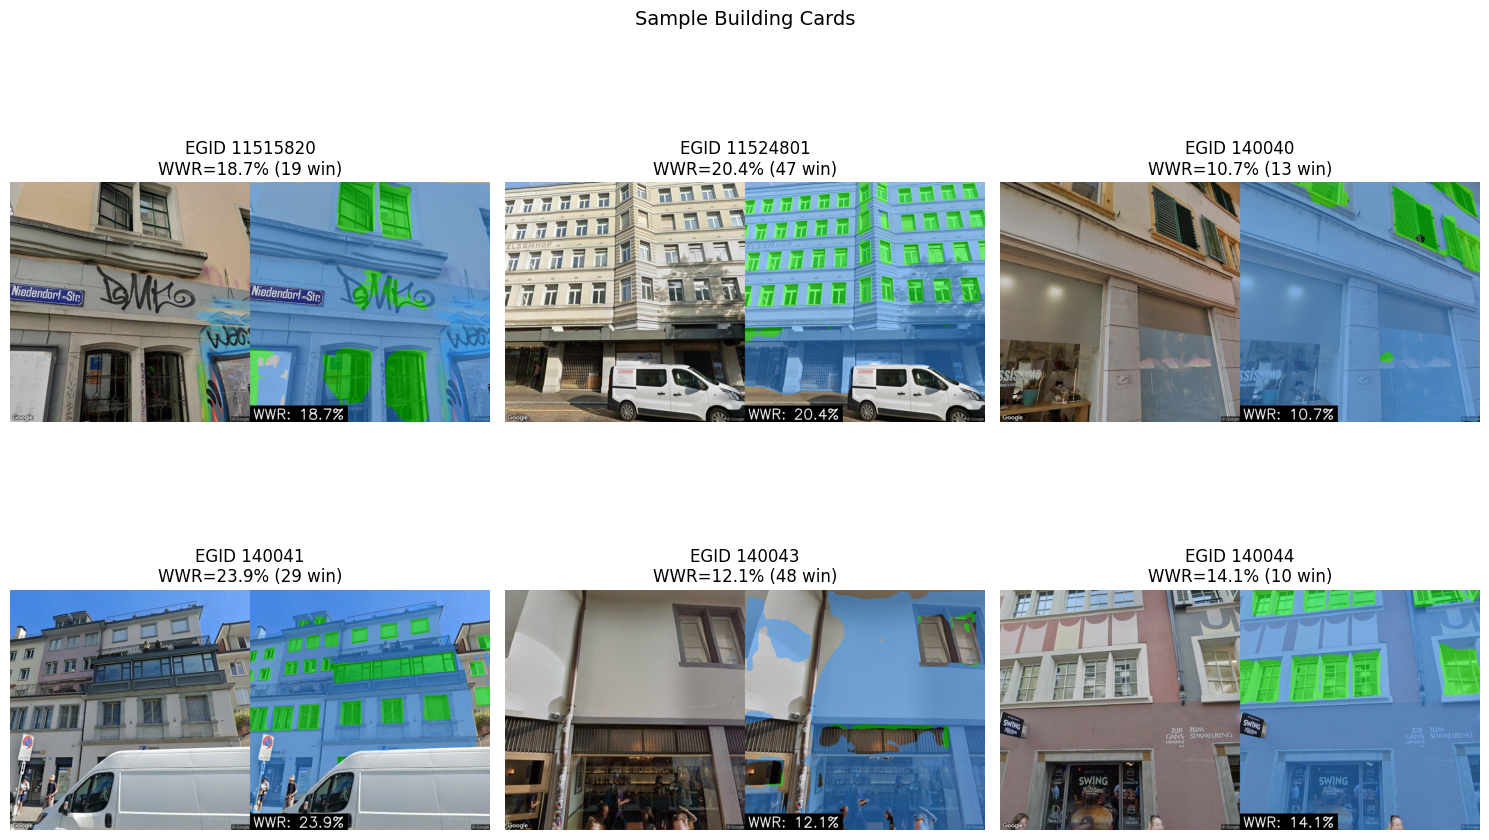

In [14]:
import cv2
from glassscan.visualise.export import create_building_card

n_show = min(6, len(result.wwr_results))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue

    wwr_r = result.wwr_results[i]
    # Match primary view (view_index=0) for both image and segmentation
    img = next((im for im in result.images if im.egid == wwr_r.egid and im.view_index == 0), None)
    seg = next((s for s in result.segmentations if s.egid == wwr_r.egid and getattr(s, 'view_index', 0) == 0), None)

    if img is not None and seg is not None:
        card = create_building_card(img.image, seg.mask, wwr_r.wwr)
        ax.imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))

    ax.set_title(f"EGID {wwr_r.egid}\nWWR={wwr_r.wwr:.1%} ({wwr_r.n_windows} win)")
    ax.axis("off")

plt.suptitle("Sample Building Cards", fontsize=14)
plt.tight_layout()
plt.show()

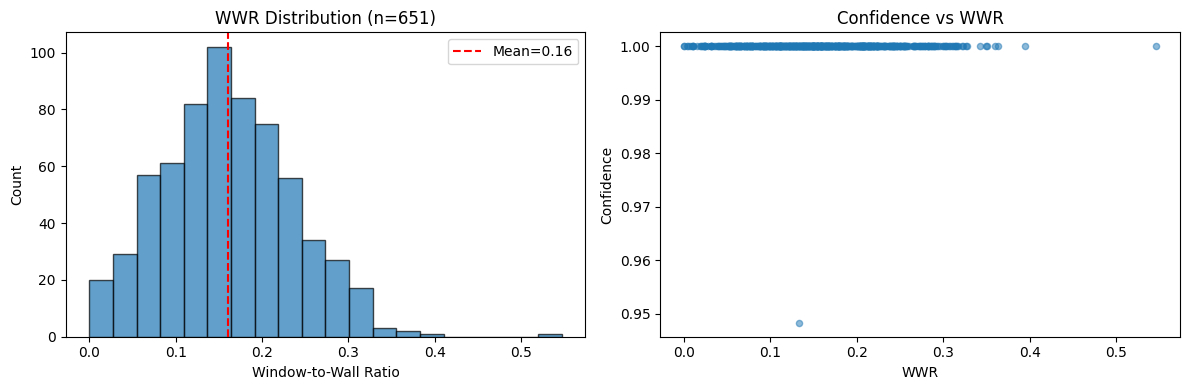

Mean WWR:   0.161
Median WWR: 0.157
Std:        0.075
Range:      0.000 -- 0.547


In [15]:
wwrs = [r.wwr for r in result.wwr_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(wwrs, bins=20, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Window-to-Wall Ratio")
ax1.set_ylabel("Count")
ax1.set_title(f"WWR Distribution (n={len(wwrs)})")
ax1.axvline(np.mean(wwrs), color="red", linestyle="--", label=f"Mean={np.mean(wwrs):.2f}")
ax1.legend()

confs = [r.confidence for r in result.wwr_results]
ax2.scatter(wwrs, confs, alpha=0.5, s=20)
ax2.set_xlabel("WWR")
ax2.set_ylabel("Confidence")
ax2.set_title("Confidence vs WWR")

plt.tight_layout()
plt.show()

print(f"Mean WWR:   {np.mean(wwrs):.3f}")
print(f"Median WWR: {np.median(wwrs):.3f}")
print(f"Std:        {np.std(wwrs):.3f}")
print(f"Range:      {min(wwrs):.3f} -- {max(wwrs):.3f}")

In [16]:
# Filter out bad images (indoor shots, panoramas with little visible facade)
MIN_FACADE_PX = 20_000  # ~5% of 640x640 image

before = len(result.wwr_results)
good_egids = {
    r.egid for r in result.wwr_results
    if (r.window_area_px + r.wall_area_px) >= MIN_FACADE_PX
}

result.wwr_results = [r for r in result.wwr_results if r.egid in good_egids]
result.images = [im for im in result.images if im.egid in good_egids]
result.segmentations = [s for s in result.segmentations if s.egid in good_egids]
result.rectified = [r for r in result.rectified if r.egid in good_egids]

print(f"Filtered: {before} -> {len(result.wwr_results)} ({before - len(result.wwr_results)} removed)")
wwrs = [r.wwr for r in result.wwr_results]
print(f"Mean WWR after filter: {np.mean(wwrs):.3f}")

Filtered: 651 -> 651 (0 removed)
Mean WWR after filter: 0.161


## 4. LLM View Quality Scoring

After running the pipeline, use a separate Claude Code session to score each
overlay image and produce `weights.json`. This improves WWR aggregation by
down-weighting bad views (occluded, zoomed in, poor segmentation).

**Instructions for Claude Code CLI:**

```
Read src/glassscan/scoring_prompt.md for the scoring rubric.

Find which buildings still need scoring:
    from glassscan.wwr import unscored_egids
    unscored = unscored_egids(raw_wwr, "data/zurich_central/weights.json")

For each unscored EGID, read the overlay images at:
    dashboard/public/overlay/{egid}.jpg        (primary view)
    dashboard/public/overlay/{egid}_v1.jpg     (view 1)
    dashboard/public/overlay/{egid}_v2.jpg     (view 2)

Score each image on the 6 criteria in the rubric, compute the geometric
mean, and write results to data/zurich_central/weights.json.

Process in batches of ~50 buildings. Output each batch's JSON so progress
is saved incrementally.
```

After scoring, run the cell below to apply the weights.

In [17]:
# Re-aggregate WWR with LLM weights (run after Claude Code scoring session)
from glassscan.wwr import aggregate_wwr, unscored_egids

weights_path = OUTPUT_DIR / "weights.json"

unscored = unscored_egids(raw_wwr, weights_path)
print(f"{len(unscored)} buildings still unscored")

result.wwr_results = aggregate_wwr(raw_wwr, weights_file=weights_path)
wwrs = [r.wwr for r in result.wwr_results]
print(f"Aggregated {len(result.wwr_results)} buildings (mean={np.mean(wwrs):.3f})")

2026-04-12 02:43:21,788 INFO Loaded weights for 651 buildings from /Users/lukemarinos/WORK/glassscan/data/zurich_central/weights.json
2026-04-12 02:43:21,789 INFO EGID 11515820: aggregated 3 views -> WWR=0.187 (weights=['0.6', '0.8', '0.4'])
2026-04-12 02:43:21,789 INFO EGID 11524801: aggregated 3 views -> WWR=0.205 (weights=['0.9', '0.7', '0.5'])
2026-04-12 02:43:21,789 INFO EGID 140040: aggregated 3 views -> WWR=0.115 (weights=['0.5', '0.7', '0.7'])
2026-04-12 02:43:21,790 INFO EGID 140041: aggregated 3 views -> WWR=0.234 (weights=['0.8', '0.4', '0.7'])
2026-04-12 02:43:21,790 INFO EGID 140043: aggregated 3 views -> WWR=0.177 (weights=['0.3', '0.8', '0.4'])
2026-04-12 02:43:21,790 INFO EGID 140044: aggregated 3 views -> WWR=0.130 (weights=['0.6', '0.7', '0.5'])
2026-04-12 02:43:21,790 INFO EGID 140046: aggregated 3 views -> WWR=0.111 (weights=['0.5', '0.6', '0.4'])
2026-04-12 02:43:21,790 INFO EGID 140047: aggregated 3 views -> WWR=0.106 (weights=['0.7', '0.4', '0.7'])
2026-04-12 02:

0 buildings still unscored
Aggregated 651 buildings (mean=0.166)


## 5. Export to Dashboard

Writes `buildings.json` + building card images to the dashboard's `public/` folder.

Then open the dashboard:
```bash
cd src/glassscan/visualise/dashboard
npm run dev
```

In [20]:
import importlib
import glassscan.visualise.export
importlib.reload(glassscan.visualise.export)
from glassscan.visualise.export import export_results

export_results(
    result, DASHBOARD_DIR,
    metadata_df=buildings_df,
    per_view_wwr=raw_wwr,
    weights_file=OUTPUT_DIR / "weights.json",
)

print(f"Exported to {DASHBOARD_DIR}")
print(f"\nOpen the dashboard:")
print(f"  cd {PROJECT_ROOT}/src/glassscan/visualise/dashboard")
print(f"  npm run dev")

2026-04-14 23:27:03,513 INFO Exported 651 buildings (651 measured, 0 predicted) to /Users/lukemarinos/WORK/glassscan/src/glassscan/visualise/dashboard/public


Exported to /Users/lukemarinos/WORK/glassscan/src/glassscan/visualise/dashboard/public

Open the dashboard:
  cd /Users/lukemarinos/WORK/glassscan/src/glassscan/visualise/dashboard
  npm run dev


## 6. Prediction Pipeline (Optional)

Train on the measured buildings + metadata, predict WWR for buildings without Street View coverage.
Needs at least ~10 measured buildings to train a useful model.

In [ ]:
from glassscan.pipeline import run_prediction_pipeline

measured_egids = {r.egid for r in result.wwr_results}
predict_df = buildings_df[~buildings_df["egid"].isin(measured_egids)]

if len(result.wwr_results) >= 10 and len(predict_df) > 0:
    pred_result = run_prediction_pipeline(
        result.wwr_results,
        buildings_df,
        predict_df=predict_df,
        model_path=OUTPUT_DIR / "wwr_model.joblib",
    )

    result.model = pred_result.model
    result.predictions = pred_result.predictions
    print(f"Predicted WWR for {len(result.predictions)} additional buildings")

    # Re-export with predictions included
    export_results(
        result, DASHBOARD_DIR,
        metadata_df=buildings_df,
        per_view_wwr=raw_wwr,
        weights_file=OUTPUT_DIR / "weights.json",
    )
    print("Re-exported with predictions")
else:
    print(f"Need >= 10 CV results to train (have {len(result.wwr_results)})")
    if len(predict_df) == 0:
        print("No buildings left to predict for")